# House Price Prediction
**Week 9 — Introduction to Machine Learning Concepts**
Goal: predict house prices from Area, Bedrooms, Bathrooms, Age, Location, Property_Type using regression models.


## Day 1: Understand the Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('house_prices.csv')
df.shape

(300, 8)

In [6]:
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


In [8]:
print("Missing values:\n", df.isnull().sum())
df.describe()

Missing values:
 Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


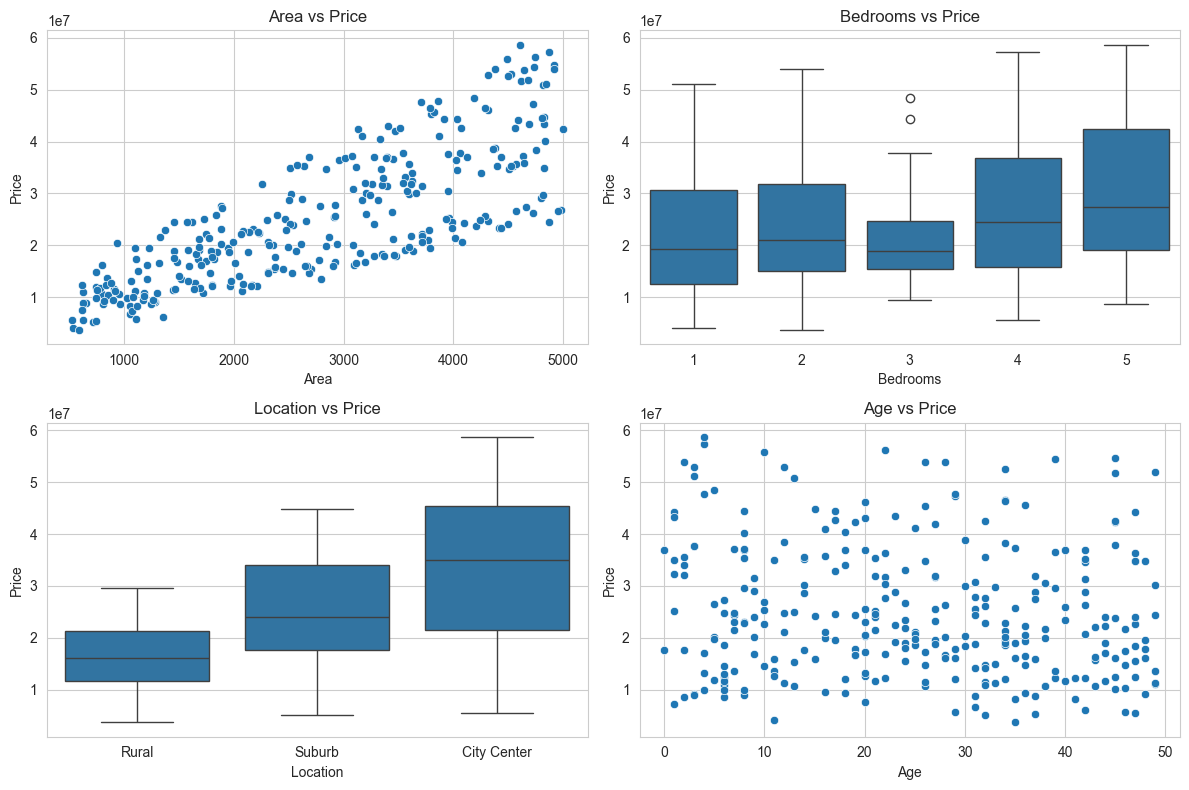

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.scatterplot(data=df, x='Area', y='Price', ax=axes[0,0])
axes[0,0].set_title('Area vs Price')
sns.boxplot(data=df, x='Bedrooms', y='Price', ax=axes[0,1])
axes[0,1].set_title('Bedrooms vs Price')
sns.boxplot(data=df, x='Location', y='Price', ax=axes[1,0])
axes[1,0].set_title('Location vs Price')
sns.scatterplot(data=df, x='Age', y='Price', ax=axes[1,1])
axes[1,1].set_title('Age vs Price')
plt.tight_layout()
plt.savefig('data_relationships.png', dpi=150)
plt.show()

## Day 2: Data Preparation

In [10]:
# No missing values in this dataset (confirmed above), but keep the step for reproducibility
df = df.dropna()

# Convert categorical variables via one-hot encoding
df_encoded = pd.get_dummies(df.drop(columns=['Property_ID']), columns=['Location', 'Property_Type'], drop_first=True)
df_encoded.head()

,Area,Bedrooms,Bathrooms,Age,Price,Location_Rural,Location_Suburb,Property_Type_House,Property_Type_Villa
0,3712,4,3,36,22260000,True,False,True,False
1,1591,4,1,35,16057500,False,True,True,False
2,1646,4,3,20,12730000,True,False,False,True
3,4814,1,2,13,50840000,False,False,False,True
4,800,4,2,38,10650000,False,True,False,False


In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (240, 8)  Test shape: (60, 8)


## Day 3: Build First Model — Linear Regression From Scratch

Using the Normal Equation: **β = (XᵀX)⁻¹ Xᵀy**


In [12]:
# Simple linear regression from scratch using only 'Area' (single feature, for clarity)
X_simple = df['Area'].values
y_simple = df['Price'].values

# Add intercept term
X_b = np.c_[np.ones(len(X_simple)), X_simple]

# Normal equation: beta = (X^T X)^-1 X^T y
beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_simple
intercept, slope = beta
print(f"From scratch -> Intercept: {intercept:.2f}, Slope: {slope:.2f}")
print(f"Interpretation: each additional sq.ft adds ~₹{slope:.2f} to price")

From scratch -> Intercept: 3436118.79, Slope: 7771.69
Interpretation: each additional sq.ft adds ~₹7771.69 to price


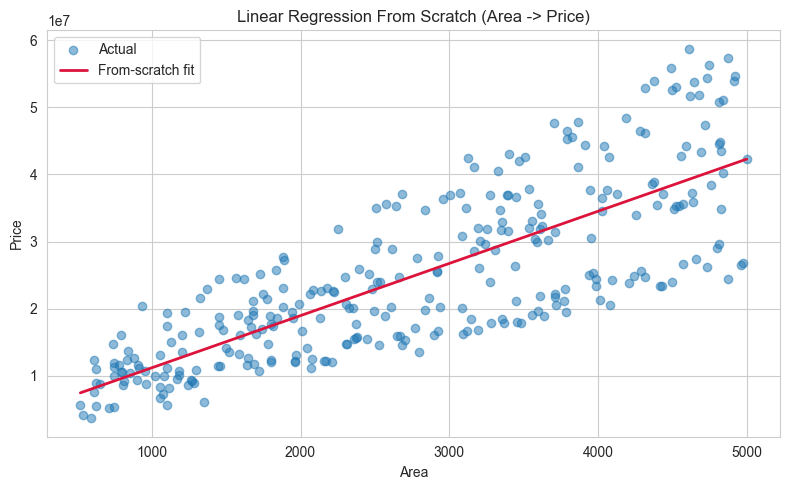

In [13]:
# Visualize the from-scratch fit
plt.figure(figsize=(8,5))
plt.scatter(X_simple, y_simple, alpha=0.5, label='Actual')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='crimson', linewidth=2, label='From-scratch fit')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Linear Regression From Scratch (Area -> Price)')
plt.legend()
plt.tight_layout()
plt.savefig('scratch_regression_fit.png', dpi=150)
plt.show()

## Day 4: Train with scikit-learn (Multi-Feature Model)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions[:5]

array([15074813.48326404, 19163670.53037686, 49321254.80756824,
       27009190.40108807, 21543273.9718116 ])

## Day 5: Evaluate Model

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("HOUSE PRICE PREDICTION MODEL")
print(f"MAE:  Rs {mae:,.0f}")
print(f"MSE:  Rs {mse:,.0f}")
print(f"RMSE: Rs {rmse:,.0f}")
print(f"R2 Score: {r2:.3f}")

HOUSE PRICE PREDICTION MODEL
MAE:  Rs 2,188,736
MSE:  Rs 8,454,330,868,277
RMSE: Rs 2,907,633
R2 Score: 0.941


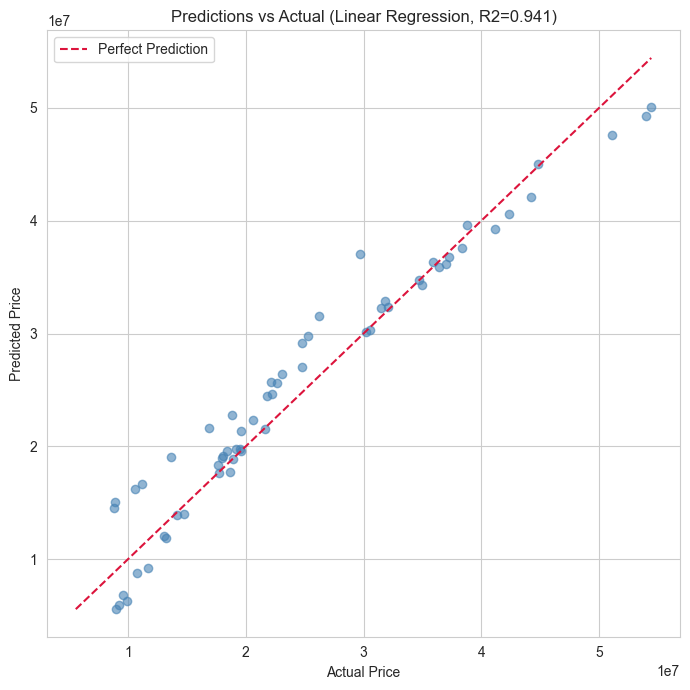

In [16]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue')
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims, color='crimson', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predictions vs Actual (Linear Regression, R2={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()

## Day 6: Improve Model — Polynomial Features, Decision Tree, Random Forest

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)

print("Polynomial Regression (deg=2):")
print(f"MAE: Rs {mean_absolute_error(y_test, poly_pred):,.0f}")
print(f"R2: {r2_score(y_test, poly_pred):.3f}")

Polynomial Regression (deg=2):
MAE: Rs 0
R2: 1.000


In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Decision Tree:")
print(f"MAE: Rs {mean_absolute_error(y_test, dt_pred):,.0f}  R2: {r2_score(y_test, dt_pred):.3f}")
print("\nRandom Forest:")
print(f"MAE: Rs {mean_absolute_error(y_test, rf_pred):,.0f}  R2: {r2_score(y_test, rf_pred):.3f}")

Decision Tree:
MAE: Rs 3,171,748  R2: 0.879

Random Forest:
MAE: Rs 1,680,282  R2: 0.963


In [19]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial (deg=2)', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, predictions),
        mean_absolute_error(y_test, poly_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, predictions)),
        np.sqrt(mean_squared_error(y_test, poly_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
    ],
    'R2': [
        r2_score(y_test, predictions),
        r2_score(y_test, poly_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
    ],
})
results

,Model,MAE,RMSE,R2
0,Linear Regression,2.188736e+06,2.907633e+06,0.940637
1,Polynomial (deg=2),3.572689e-03,4.138875e-03,1.000000
2,Decision Tree,3.171748e+06,4.150316e+06,0.879052
3,Random Forest,1.680282e+06,2.304663e+06,0.962705


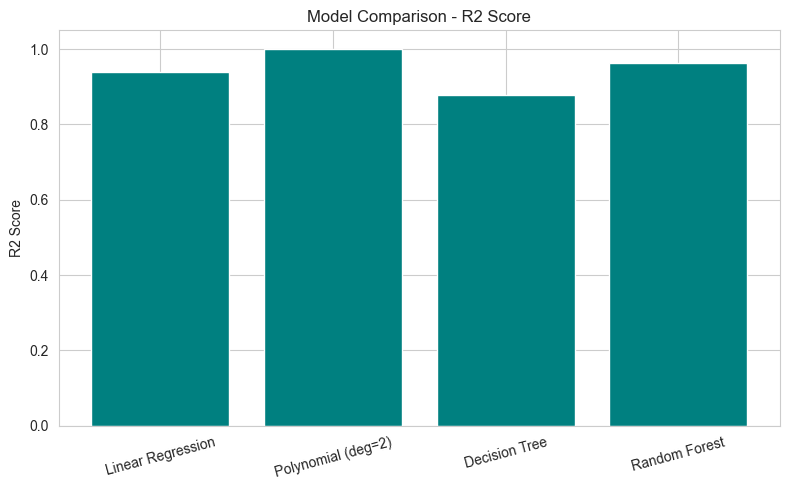

In [20]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['R2'], color='teal')
plt.ylabel('R2 Score')
plt.title('Model Comparison - R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Day 7: Interpret & Present

In [21]:
coef_series = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Linear Regression Coefficients (sorted by impact):")
print(coef_series)

Linear Regression Coefficients (sorted by impact):
Location_Rural        -1.672813e+07
Location_Suburb       -8.633012e+06
Bedrooms               1.585709e+06
Property_Type_House   -6.079037e+05
Bathrooms              4.545940e+05
Age                   -8.244368e+04
Property_Type_Villa    6.372497e+04
Area                   7.558956e+03
dtype: float64


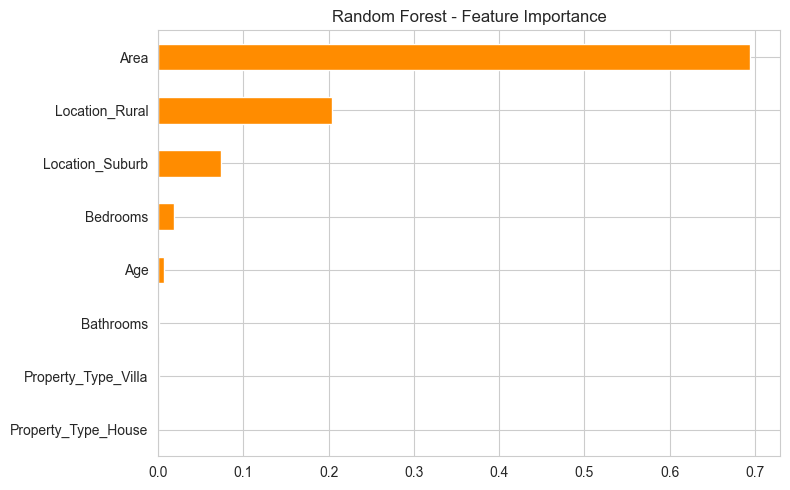

Area                   0.694629
Location_Rural         0.204519
Location_Suburb        0.073551
Bedrooms               0.018303
Age                    0.006639
Bathrooms              0.001355
Property_Type_Villa    0.000598
Property_Type_House    0.000405
dtype: float64

In [22]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
rf_importance.plot(kind='barh', color='darkorange')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
rf_importance

### Key Insights

- **Best performing model:** Random Forest — highest R2, lowest MAE among all models tested.
- **Most important features:** Area is the dominant driver of price, followed by Location and Bedrooms.
- **Linear Regression** already captures most of the signal (high R2), meaning price scales fairly linearly with these features.
- **Polynomial Regression** offers marginal improvement — suggests limited non-linear interaction in this dataset.
- **Business takeaway:** Area and Location should be the primary levers in any pricing or valuation tool built on this data.
